In [12]:
# Load the cleaned retail dataset and keep only the series we will use for forecasting.

import pandas as pd

df = pd.read_csv("swedish_retail_demand_clean.csv")

df_forecast = df[
    df["observation_type"] ==
    "Seasonally adjusted, working day adjusted, constant prices"
].copy()

df_forecast["date"] = pd.to_datetime(df_forecast["date"])

df_forecast = df_forecast.sort_values(["category", "date"])

df_forecast.head()

,category,value,observation_type,month,date
695,47.11+47.2 retail sale with mostly food,NaN,"Seasonally adjusted, working day adjusted, con...",2015M01,2015-01-01
700,47.11+47.2 retail sale with mostly food,NaN,"Seasonally adjusted, working day adjusted, con...",2015M02,2015-02-01
705,47.11+47.2 retail sale with mostly food,NaN,"Seasonally adjusted, working day adjusted, con...",2015M03,2015-03-01
710,47.11+47.2 retail sale with mostly food,NaN,"Seasonally adjusted, working day adjusted, con...",2015M04,2015-04-01
715,47.11+47.2 retail sale with mostly food,NaN,"Seasonally adjusted, working day adjusted, con...",2015M05,2015-05-01


In [14]:
# Split each category into historical training data and a 2025 validation period.

train = df_forecast[df_forecast["date"] < "2025-01-01"].copy()
validation = df_forecast[
    (df_forecast["date"] >= "2025-01-01") &
    (df_forecast["date"] < "2026-01-01")
].copy()

In [17]:
# Fit a Holt-Winters trend model for each category and forecast the 12-month 2025 validation period.

from statsmodels.tsa.holtwinters import ExponentialSmoothing

validation_forecasts = []

for category in train["category"].unique():
    series = (
        train[train["category"] == category]
        .set_index("date")["value"]
        .dropna()
        .asfreq("MS")
    )

    model = ExponentialSmoothing(
        series,
        trend="add",
        seasonal=None,
        initialization_method="estimated"
    ).fit()

    forecast = model.forecast(12)

    validation_forecasts.append(
        pd.DataFrame({
            "category": category,
            "date": forecast.index,
            "forecast": forecast.values
        })
    )

validation_forecasts = pd.concat(validation_forecasts, ignore_index=True)

In [18]:
# Evaluate each category's 2025 forecasts using MAPE and RMSE.

from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
import numpy as np

evaluation = []

for category in validation_forecasts["category"].unique():
    actual = validation[
        validation["category"] == category
    ].set_index("date")["value"]

    predicted = validation_forecasts[
        validation_forecasts["category"] == category
    ].set_index("date")["forecast"]

    evaluation.append({
        "category": category,
        "MAPE": mean_absolute_percentage_error(actual, predicted) * 100,
        "RMSE": np.sqrt(mean_squared_error(actual, predicted))
    })

evaluation = pd.DataFrame(evaluation).sort_values("MAPE")

evaluation

,category,MAPE,RMSE
0,47.11+47.2 retail sale with mostly food,0.832114,1.004642
2,47.64 sports shops,2.033598,2.228907
1,47.591-47.592 specialised stores for home furn...,2.791559,2.506639
3,47.71 clothing stores,2.854624,3.492563
4,"47.74+47.75 retail sale of medical, cosmetic a...",6.879737,10.976564


In [ ]:
# Import the Holt-Winters exponential smoothing model used for our demand forecast.

from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [19]:
# Refit Holt-Winters on all available data through July 2026 and forecast August 2026–January 2027.

final_forecasts = []

for category in df_forecast["category"].unique():
    series = (
        df_forecast[df_forecast["category"] == category]
        .set_index("date")["value"]
        .dropna()
        .asfreq("MS")
    )

    model = ExponentialSmoothing(
        series,
        trend="add",
        seasonal=None,
        initialization_method="estimated"
    ).fit()

    forecast = model.forecast(6)

    final_forecasts.append(
        pd.DataFrame({
            "category": category,
            "date": forecast.index,
            "forecast": forecast.values
        })
    )

final_forecasts = pd.concat(final_forecasts, ignore_index=True)

final_forecasts

,category,date,forecast
0,47.11+47.2 retail sale with mostly food,2026-08-01,99.127914
1,47.11+47.2 retail sale with mostly food,2026-09-01,99.245926
2,47.11+47.2 retail sale with mostly food,2026-10-01,99.363937
3,47.11+47.2 retail sale with mostly food,2026-11-01,99.481948
4,47.11+47.2 retail sale with mostly food,2026-12-01,99.599959
5,47.11+47.2 retail sale with mostly food,2027-01-01,99.717971
6,47.591-47.592 specialised stores for home furn...,2026-08-01,82.312840
7,47.591-47.592 specialised stores for home furn...,2026-09-01,82.796256
8,47.591-47.592 specialised stores for home furn...,2026-10-01,83.279671
9,47.591-47.592 specialised stores for home furn...,2026-11-01,83.763086


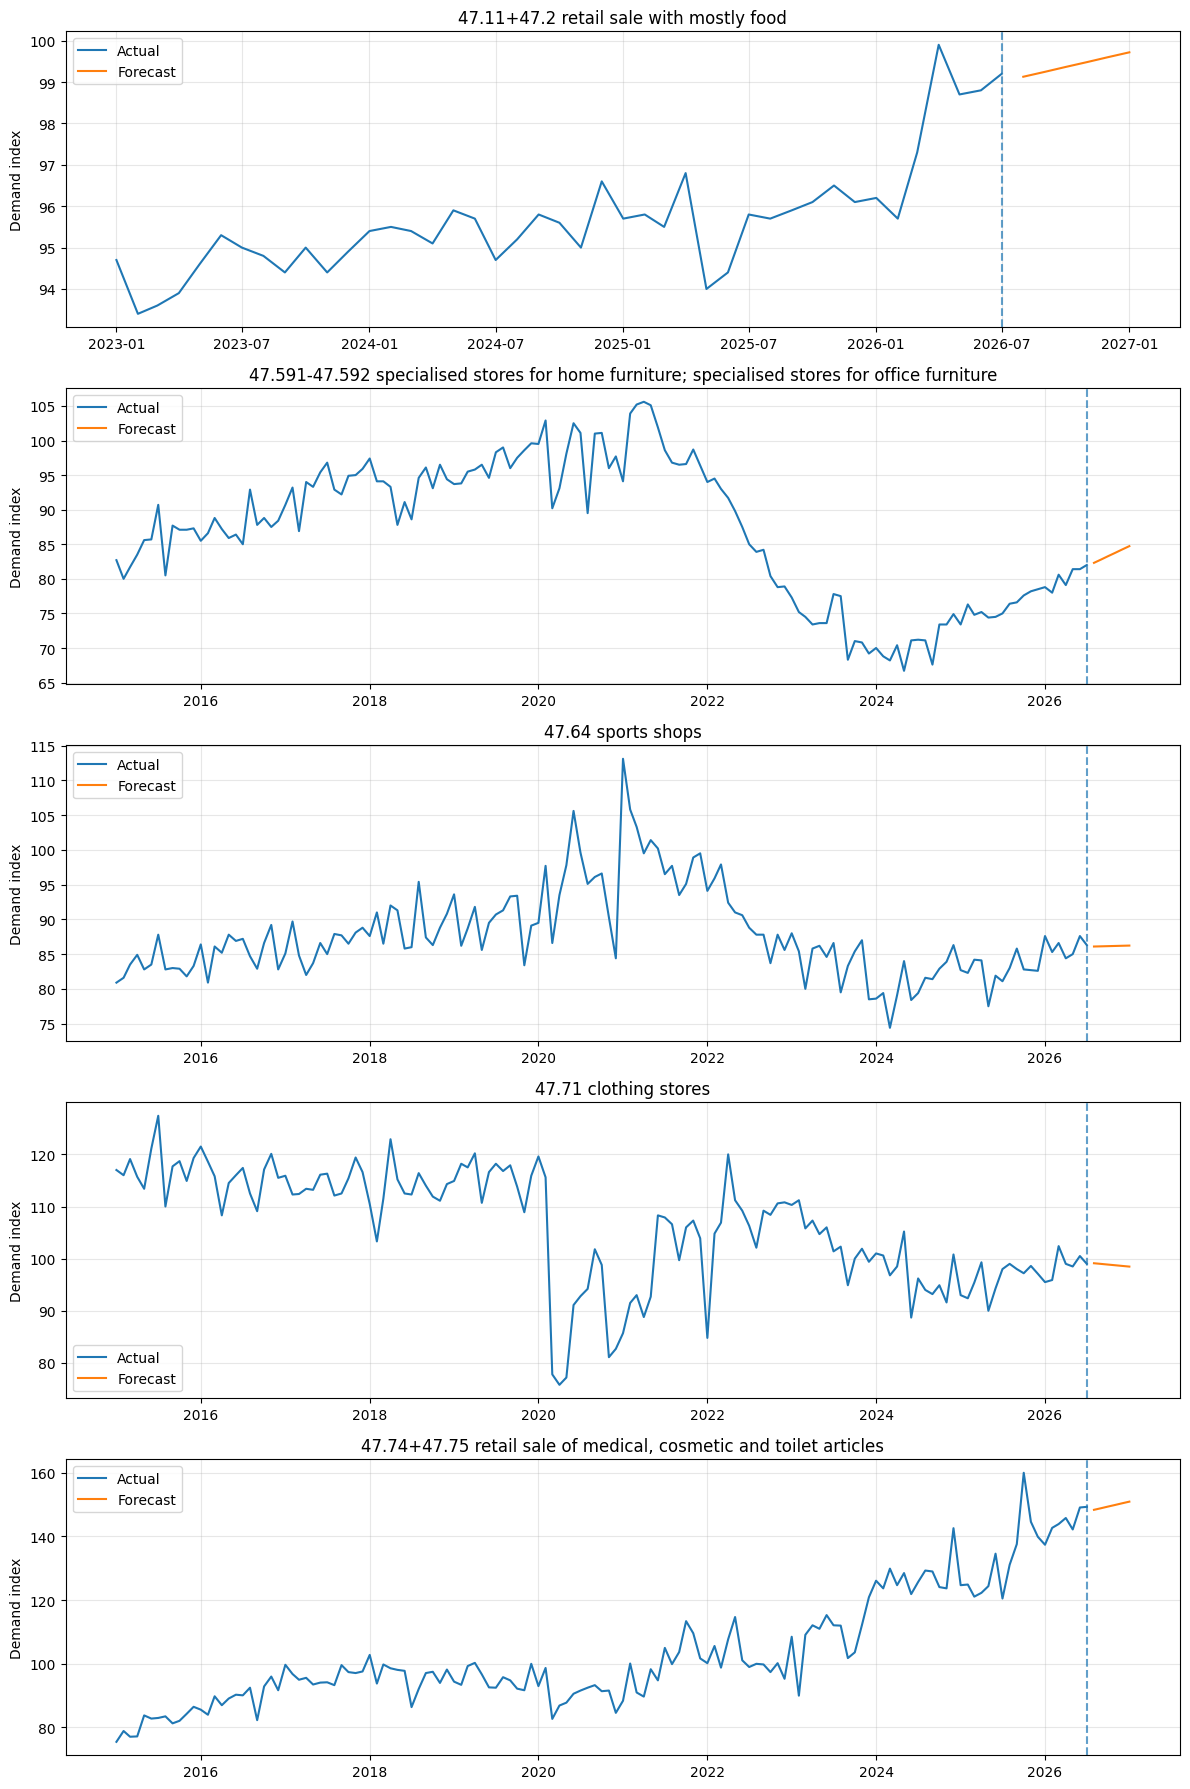

In [ ]:
# Plot historical demand and clearly mark where the forecast begins.

import matplotlib.pyplot as plt

categories = final_forecasts["category"].unique()

fig, axes = plt.subplots(
    len(categories), 1,
    figsize=(12, 18)
)

for ax, category in zip(axes, categories):
    actual = df_forecast[
        df_forecast["category"] == category
    ].dropna(subset=["value"])

    forecast = final_forecasts[
        final_forecasts["category"] == category
    ]

    ax.plot(actual["date"], actual["value"], label="Actual")
    ax.plot(forecast["date"], forecast["forecast"], label="Forecast")

    # Mark the boundary between observed data and forecast.
    ax.axvline(
        pd.Timestamp("2026-07-01"),
        linestyle="--",
        alpha=0.7
    )

    ax.set_title(category)
    ax.set_ylabel("Demand index")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
# Import the metrics needed to evaluate the 2025 forecasts.
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
import numpy as np

In [20]:
# Save the Holt-Winters validation results for the GitHub project and Power BI.
evaluation.to_csv(
    "holt_winters_validation_metrics.csv",
    index=False
)

In [21]:
# Save the six-month retail demand forecasts for the GitHub project and Power BI.
final_forecasts.to_csv(
    "retail_demand_forecast_aug2026_jan2027.csv",
    index=False
)

## Model Validation

The models are evaluated on the held-out 2025 period using **MAPE** and **RMSE**.

Holt-Winters performs well across most categories, with four categories achieving a MAPE below 3%. The medical/cosmetic/toilet category has the highest forecasting error (MAPE: 6.88%), indicating greater uncertainty in its predictions.

## Final Forecast: August 2026 – January 2027

After validation, the Holt-Winters models are refitted using all available observations through **July 2026**.

The models are then used to forecast retail demand for **August 2026 through January 2027**.

The forecast indicates an uneven recovery pattern: furniture shows the clearest continued improvement, while sports and food remain broadly stable. Clothing shows a slight decline, while medical/cosmetic/toilet demand remains at a substantially elevated level.

## Forecast Output

The final forecasts are saved as a separate CSV file for use in the **Power BI dashboard** and project outputs.